# mlr_investigation_friant.ipynb

In [45]:
import xarray as xr
import os 
import rioxarray
from pyproj import CRS, Transformer
import sys
import subprocess
import numpy as np
import pandas as pd
from pathlib import Path
import geopandas as gpd
from rasterio.enums import Resampling
from typing import List, Dict, Tuple, Optional
from datetime import datetime
import time
import importlib

In [46]:
sys.path.insert(1, '/home/rossamower/bin/scripts/')

In [47]:
import metadata as metadata
import plotting as plotting
import preprocessing as preprocessing
import lm_model as lm_model
import postprocessing as postprocessing

In [48]:
importlib.reload(metadata)
importlib.reload(plotting)
importlib.reload(preprocessing)
importlib.reload(lm_model)
importlib.reload(postprocessing)

<module 'postprocessing' from '/home/rossamower/bin/scripts/postprocessing.py'>

# Inputs

In [49]:
aso_site_name = 'FRIANT'
user_qa_level = 1 #[0 - most conservative; 1 mid; 2 most liberal]
isSplit = False
isAccum = False
aso_stack_type = 'v1'
elev_band = -1
water_year = 1997

## Metadata

In [50]:
def load_aso_metadata(aso_site_name: str,
                  config_dir: str = '/home/rossamower/work/aso/configs/',
                 ):
    cfg = metadata.load_yaml(Path(f"{config_dir}regions/{aso_site_name}.yaml"))
    elev_bin_edges_m, elev_bin_labels = metadata.get_elevation_bins(cfg)
    start_wy = int(cfg["aso_years"]["start"])
    end_wy = int(cfg["aso_years"]["end"])
    shape_fpath = cfg["data_filepaths"]["aso_shape"]
    demBin_fpath = cfg["data_filepaths"]["aso_demBin"]
    aso_spatial_fpath = cfg["data_filepaths"]["aso_spatial"]
    aso_tseries_fpath = cfg["data_filepaths"]["aso_temporal"]
    uaswe_dir = cfg["data_filepaths"]["uaswe_dir"]
    snowmodel_dir = cfg["data_filepaths"]["snowmodel_dir"]
    snodas_dir = cfg["data_filepaths"]["snodas_dir"]
    insitu_dir = cfg["data_filepaths"]["insitu_dir"]
    mlrPred_dir = cfg["data_filepaths"]["mlrPred_dir"]
    if not os.path.exists(mlrPred_dir): os.makedirs(mlrPred_dir)
    shape_crs = f'EPSG:{cfg["crs"]["epsg"]}'
    return elev_bin_labels, shape_fpath, demBin_fpath, aso_spatial_fpath, aso_tseries_fpath, snowmodel_dir, snodas_dir, insitu_dir, mlrPred_dir, uaswe_dir, shape_crs, cfg

## Load ASO

In [51]:
def load_aso_data(aso_spatial_fpath: str,
                  aso_tseries_fpath: str,
                  demBin_fpath: str,
                  shape_fpath: str,
                  shape_crs: str,
                 ):
    aso_spatial_ds = xr.open_dataset(aso_spatial_fpath,engine ='netcdf4')
    aso_demBin_ds = xr.open_dataset(demBin_fpath,engine ='netcdf4')
    aso_tseries_ds = xr.open_dataset(aso_tseries_fpath,engine ='netcdf4')
    shape_geog_gdf = gpd.read_file(shape_fpath)
    shape_proj_gdf = shape_geog_gdf.to_crs(shape_crs)

    return aso_spatial_ds, aso_demBin_ds, shape_proj_gdf, aso_tseries_ds

## Misc

In [52]:
def pad_zero(val_str):
    if len(val_str) ==1:
        return '0' + val_str
    else:
        return val_str

def dataset_to_list(ds: xr.Dataset) -> list:
    da_list = []
    for pil in ds.data_vars:
        da = ds[pil]
        da.name = pil
        da_list.append(da)
    return da_list

def snowmodel_swe_fpaths(base_dir,water_yrs,var):
    nc_lst = []
    for wy in water_yrs:
        nc_dir = f'{base_dir}wy_{wy}/netcdf/'
        for file in os.listdir(nc_dir):
            if var in file:
                nc_lst.append(nc_dir + file)
    return sorted(nc_lst)

def timing_vars(obs_data_test_ds: xr.Dataset):
    date_str = str(obs_data_test_ds.time.values[-1])[0:10]
    year_str = date_str[0:4]
    month_str = date_str[5:7]
    day_str = date_str[8:10]
    
    if int(month_str) >= 10:
        wy_str = str(int(year_str) +1)
    else:
        wy_str = year_str
    return year_str, month_str, day_str, wy_str

def get_default_settings():
    user_elevation_interval = -1
    model_num = 0   
    isMean = False
    isCombination = True
    prediction_mm_df = None
    prediction_acreFt_df = None
    prediction_pillow_df = None
    isCombination = True
    user_qa_level = 0
    QA_flag = user_qa_level + 1
    elev_band = user_elevation_interval
    return model_num,isMean,isCombination,prediction_mm_df,prediction_acreFt_df,prediction_pillow_df,user_qa_level,elev_band, QA_flag

# Preprocessing

## Default Settings

In [53]:
model_num,isMean,isCombination,prediction_mm_df,prediction_acreFt_df,prediction_pillow_df,user_qa_level,elev_band, QA_flag = get_default_settings()

## Load Metadata

In [54]:
# load metadata information.
elev_bin_labels, shape_fpath, demBin_fpath, aso_spatial_fpath, aso_tseries_fpath, snowmodel_dir, snodas_dir, insitu_dir, mlrPred_dir,uaswe_dir,shape_crs,cfg = load_aso_metadata(aso_site_name)

# pillows to exclude from QA.
exclude_pillows = cfg['pillow_api']['exclude_pillows']
elev_bin_edges_m, elev_bin_labels = metadata.get_elevation_bins(cfg)
start_wy = int(cfg["aso_years"]["start"])
end_wy = int(cfg["aso_years"]["end"])

# Load Input Data

In [55]:
# load spatial data.
aso_spatial_ds, dem_bin, shape_proj_gdf, aso_tseries_ds = load_aso_data(aso_spatial_fpath,
                                                                                aso_tseries_fpath,
                                                                                demBin_fpath,
                                                                                shape_fpath,
                                                                                shape_crs)

# obs data.
obs_data = xr.load_dataset(f'{insitu_dir}processed/pillow_wy_1980_2025_qa1.nc')
# obs test.
obs_data_test_ds = obs_data.where(obs_data.time>=np.datetime64(f'{water_year-1}-10-01'), drop = True) \
                       .where(obs_data.time<np.datetime64(f'{water_year}-10-01'), drop = True)    
# obs train.
obs_data_train_ds = obs_data.where(~obs_data.time.isin(obs_data_test_ds.time.values), drop = True)

obs_data_train_lst = dataset_to_list(obs_data_train_ds)
obs_data_test_lst = dataset_to_list(obs_data_test_ds)


# # obs training.
# obs_data_train_ds = xr.load_dataset(f'{insitu_dir}processed/pillow_wy_1980_2025_qa1.nc')
# obs_data_train_lst = dataset_to_list(obs_data_train_ds)
# # snowmodel 
# sm_train_ds = xr.open_zarr(f'{insitu_dir}hrrr_correlated_train_2017_2025_dowy.zarr', consolidated=False)
# sm_test_ds = xr.open_zarr(f'{insitu_dir}hrrr_correlated_test_2026.zarr', consolidated=False)

# # testing raw.
# obs_data_test_ds_raw = xr.load_dataset(f'{insitu_dir}raw/{aso_site_name}_insitu_obs_daily_wy_2026.nc')
# # match times.
# obs_data_test_ds_raw = obs_data_test_ds_raw.sel(time = sm_test_ds.time)
# obs_data_test_lst_raw = dataset_to_list(obs_data_test_ds_raw)
# # testing qa.
# obs_data_test_ds = xr.load_dataset(f'{insitu_dir}processed/{aso_site_name}_insitu_obs_daily_wy_2026.nc')
# # match times.
# # obs_data_test_ds = obs_data_test_ds.sel(time = sm_test_ds.time)
# obs_data_test_ds = obs_data_test_ds.where(obs_data_test_ds.time.isin(sm_test_ds.time.values),drop = True)
# obs_data_test_lst = dataset_to_list(obs_data_test_ds)
# initial pillow list.
pillows = list(obs_data_test_ds.data_vars)
pillows = [i for i in pillows if i not in exclude_pillows]
# get timing variables.
year_str, month_str, day_str, wy_str = timing_vars(obs_data_test_ds)
# load UASWE data.
# uaswe_acreFt_df = pd.read_csv(f'{uaswe_dir}mean_swe_uaswe_acreFt_wy{water_year}.csv')
# uaswe_m_df = pd.read_csv(f'{uaswe_dir}mean_swe_uaswe_m_wy{water_year}.csv')
# # load SNODAS data.
# snodas_acreFt_df = pd.read_csv(f'{snodas_dir}mean_swe_snodas_acreFt_wy{water_year}.csv')
# snodas_m_df = pd.read_csv(f'{snodas_dir}mean_swe_snodas_m_wy{water_year}.csv')
# # load SnowModel data.
# sm_acreFt_df = pd.read_csv(f'{snowmodel_dir}mean_swe_snowmodel_acreFt_wy{water_year}.csv')
# sm_m_df = pd.read_csv(f'{snowmodel_dir}mean_swe_snowmodel_m_wy{water_year}.csv')
# # convert date columns to datetime.
# snodas_acreFt_df['Date'] = pd.to_datetime(snodas_acreFt_df['Date'])
# snodas_m_df['Date'] = pd.to_datetime(snodas_m_df['Date'])
# uaswe_acreFt_df['Date'] = pd.to_datetime(uaswe_acreFt_df['Date'])
# uaswe_m_df['Date'] = pd.to_datetime(uaswe_m_df['Date'])
# sm_acreFt_df['Date'] = pd.to_datetime(sm_acreFt_df['Date'])
# sm_m_df['Date'] = pd.to_datetime(sm_m_df['Date'])

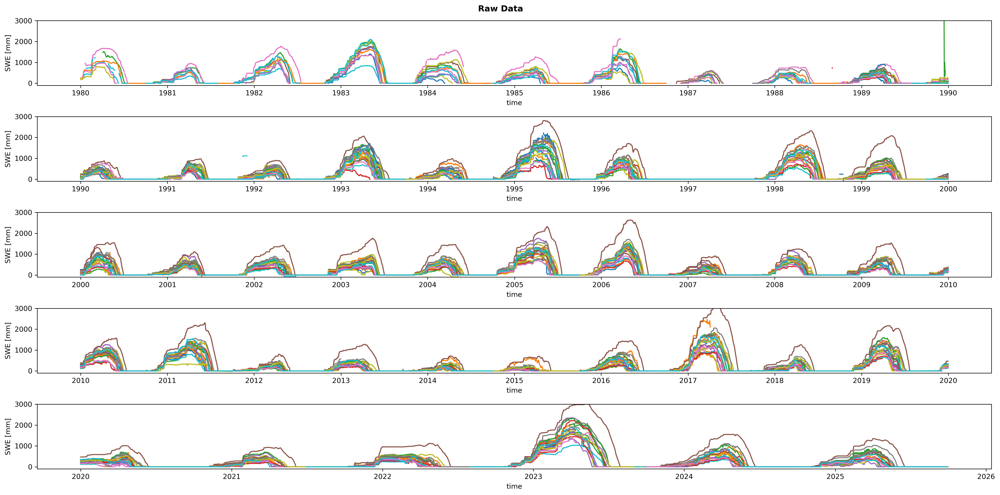

In [56]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(5,1,dpi = 300,figsize = (20,10))
count = 0
for yr in [1980,1990,2000,2010,2020]:
    ds_slice = obs_data_train_ds.where(obs_data_train_ds.time.dt.year >=yr,drop = True) \
                     .where(obs_data_train_ds.time.dt.year <= yr+9,drop = True)
    for pil in ds_slice.data_vars:
        ds_slice[pil].plot(ax=ax[count])
    ax[count].set_ylim(-100,3000)
    ax[count].set_ylabel('SWE [mm]')
    count += 1
    
plt.suptitle('Raw Data',fontweight = 'bold')
plt.tight_layout()

# Load Model Output

In [57]:
def load_model_output(seasonal_dir: str,
                      aso_stack_type: str,
                      mlrPred_dir: str,
                      var: str = 'mm'):
    if var not in ['mm','acreFt','pillows']:
        sys.exit('Incorrect variable passed!')

    output_path = f'{mlrPred_dir}{aso_stack_type}/{seasonal_dir}/{var}/'
    # print(output_path)

    csv_lst = [output_path + i for i in os.listdir(output_path) if '.csv' in i]
    # print(csv_lst)
    count = 0
    for i in sorted(csv_lst):
        if count == 0:
            df_all = pd.read_csv(i)
        else:
            df_all = pd.concat([df_all,pd.read_csv(i)])
        count+=1
    df_all = df_all.reset_index().drop(columns = 'index')
    df_all['Date'] = pd.to_datetime(df_all['Date'])
    df_all["Wateryear"] = np.where((df_all['Date'].dt.month >= 10), df_all['Date'].dt.year+1, df_all['Date'].dt.year)
    
    return df_all


In [58]:
season = 'season'
# v0 --------------------------------------------------
aso_stack_type = 'v0'
var = 'mm' # mm, acreFt, pillows
pred_df_v0_mm = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
var = 'acreFt' # mm, acreFt, pillows
pred_df_v0_acreFt = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
var = 'pillows' # mm, acreFt, pillows
pred_df_v0_pillows = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
# v1 --------------------------------------------------
aso_stack_type = 'v1'
var = 'mm' # mm, acreFt, pillows
pred_df_v1_mm = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
var = 'acreFt' # mm, acreFt, pillows
pred_df_v1_acreFt = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
var = 'pillows' # mm, acreFt, pillows
pred_df_v1_pillows = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)

# v2 --------------------------------------------------
aso_stack_type = 'v2'
var = 'mm' # mm, acreFt, pillows
pred_df_v2_mm = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
var = 'acreFt' # mm, acreFt, pillows
pred_df_v2_acreFt = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
var = 'pillows' # mm, acreFt, pillows
pred_df_v2_pillows = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)

# v3 --------------------------------------------------
aso_stack_type = 'v3'
var = 'mm' # mm, acreFt, pillows
pred_df_v3_mm = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
var = 'acreFt' # mm, acreFt, pillows
pred_df_v3_acreFt = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
var = 'pillows' # mm, acreFt, pillows
pred_df_v3_pillows = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)

# v4 --------------------------------------------------
aso_stack_type = 'v4'
var = 'mm' # mm, acreFt, pillows
pred_df_v4_mm = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
var = 'acreFt' # mm, acreFt, pillows
pred_df_v4_acreFt = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
var = 'pillows' # mm, acreFt, pillows
pred_df_v4_pillows = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)

# v5 --------------------------------------------------
aso_stack_type = 'v5'
var = 'mm' # mm, acreFt, pillows
pred_df_v5_mm = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
var = 'acreFt' # mm, acreFt, pillows
pred_df_v5_acreFt = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
var = 'pillows' # mm, acreFt, pillows
pred_df_v5_pillows = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)


# Load UASWE Output

In [59]:
uaswe_dir = '/home/rossamower/work/aso/data/uaswe/FRIANT/'

uaswe_files = sorted([uaswe_dir + i for i in os.listdir(uaswe_dir)])
uaswe_files

['/home/rossamower/work/aso/data/uaswe/FRIANT/USCASJ_uaswe_wy_1982.csv',
 '/home/rossamower/work/aso/data/uaswe/FRIANT/USCASJ_uaswe_wy_1983.csv',
 '/home/rossamower/work/aso/data/uaswe/FRIANT/USCASJ_uaswe_wy_1984.csv',
 '/home/rossamower/work/aso/data/uaswe/FRIANT/USCASJ_uaswe_wy_1985.csv',
 '/home/rossamower/work/aso/data/uaswe/FRIANT/USCASJ_uaswe_wy_1986.csv',
 '/home/rossamower/work/aso/data/uaswe/FRIANT/USCASJ_uaswe_wy_1987.csv',
 '/home/rossamower/work/aso/data/uaswe/FRIANT/USCASJ_uaswe_wy_1988.csv',
 '/home/rossamower/work/aso/data/uaswe/FRIANT/USCASJ_uaswe_wy_1989.csv',
 '/home/rossamower/work/aso/data/uaswe/FRIANT/USCASJ_uaswe_wy_1990.csv',
 '/home/rossamower/work/aso/data/uaswe/FRIANT/USCASJ_uaswe_wy_1991.csv',
 '/home/rossamower/work/aso/data/uaswe/FRIANT/USCASJ_uaswe_wy_1992.csv',
 '/home/rossamower/work/aso/data/uaswe/FRIANT/USCASJ_uaswe_wy_1993.csv',
 '/home/rossamower/work/aso/data/uaswe/FRIANT/USCASJ_uaswe_wy_1994.csv',
 '/home/rossamower/work/aso/data/uaswe/FRIANT/USCAS

In [60]:
count = 0
for file in uaswe_files:
    df_year = pd.read_csv(file).rename(columns = {'Unnamed: 0':'Date'})
    df_year['Date'] = pd.to_datetime(df_year['Date'], format="%Y%m%d")
    df_year["Wateryear"] = np.where((df_year['Date'].dt.month >= 10), df_year['Date'].dt.year+1, df_year['Date'].dt.year)
    df_year['Total'] = df_year['Total'] / 10
    if count == 0:
        uaswe_df = df_year
    else:
        uaswe_df = pd.concat([uaswe_df,df_year])
    count += 1 
uaswe_df

,Date,noData,<7000,7000-8000,8000-9000,9000-10000,10000-11000,11000-12000,>12000,Total,Wateryear
0,1981-10-01,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1982
1,1981-10-02,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1982
2,1981-10-03,0.024427,0.0,0.000000,0.000000,0.000000,0.029240,0.541688,1.262298,0.183323,1982
3,1981-10-04,0.370611,0.0,0.000166,0.039213,0.606176,1.345734,1.889970,2.545679,0.642694,1982
4,1981-10-05,0.447811,0.0,0.000417,0.053067,0.839278,1.674681,2.042372,2.597244,0.720706,1982
...,...,...,...,...,...,...,...,...,...,...,...
359,2025-09-25,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2025
360,2025-09-26,0.019805,0.0,0.000000,0.000000,0.000000,0.000000,0.017892,0.405038,0.042293,2025
361,2025-09-27,0.004388,0.0,0.000000,0.000000,0.000000,0.000000,0.000712,0.067993,0.006871,2025
362,2025-09-28,0.000383,0.0,0.000000,0.000000,0.000000,0.000000,0.000112,0.013279,0.001339,2025


## v0

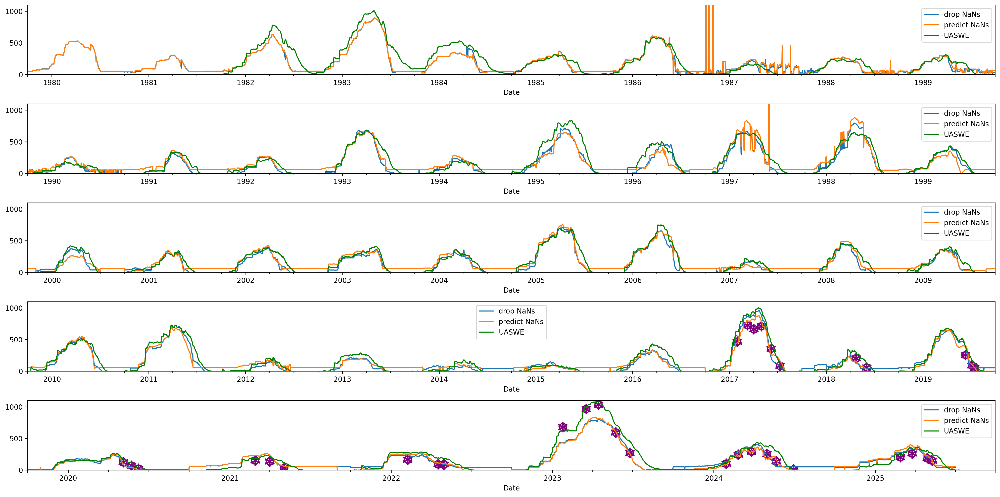

In [61]:
fig,ax = plt.subplots(5,1,dpi = 200,figsize = (20,10))
count = 0
for yr in [1980,1990,2000,2010,2020]:
    df_slice = pred_df_v0_mm[(pred_df_v0_mm['Wateryear'] >= yr) & (pred_df_v0_mm['Wateryear'] <= yr+9)]
    uaswe_slice = uaswe_df[(uaswe_df['Wateryear'] >= yr) & (uaswe_df['Wateryear'] <= yr+9)]
    aso_tseries_slice = aso_tseries_ds.where(aso_tseries_ds.date.dt.year >= yr).where(aso_tseries_ds.date.dt.year <= yr+9)
    df_slice[df_slice['Training Infer NaNs'] == 'drop NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C0',label = 'drop NaNs')
    df_slice[df_slice['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C1',label = 'predict NaNs')
    uaswe_slice.plot(ax=ax[count],x = 'Date', y = 'Total', color = 'green',label = 'UASWE')
    ax[count].scatter(aso_tseries_slice.date.values,aso_tseries_slice.aso_swe[:,-1].values,marker=u'$\u2744$', s=200,color = 'purple',label = 'ASO')
    ax[count].set_ylim(0,1100)
    count += 1
plt.tight_layout()

In [62]:
# fig,ax = plt.subplots(5,1,dpi = 200,figsize = (20,10))
# count = 0
# for yr in [1980,1990,2000,2010,2020]:
#     df_slice = pred_df_v0_mm[(pred_df_v0_acreFt['Wateryear'] >= yr) & (pred_df_v0_acreFt['Wateryear'] <= yr+9)]
#     uaswe_slice = uaswe_df[(uaswe_df['Wateryear'] >= yr) & (uaswe_df['Wateryear'] <= yr+9)]
#     # aso_tseries_slice = aso_tseries_ds.where(aso_tseries_ds.date.dt.year >= yr).where(aso_tseries_ds.date.dt.year <= yr+9)
#     df_slice[df_slice['Training Infer NaNs'] == 'drop NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C0',label = 'drop NaNs')
#     df_slice[df_slice['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C1',label = 'predict NaNs')
#     uaswe_slice.plot(ax=ax[count],x = 'Date', y = 'Total', color = 'green',label = 'UASWE')
#     ax[count].scatter(aso_tseries_slice.date.values,aso_tseries_slice.aso_swe[:,-1].values,marker=u'$\u2744$', s=200,color = 'purple',label = 'ASO')
#     ax[count].set_ylim(0,1100)
#     count += 1
# plt.tight_layout()

## v1

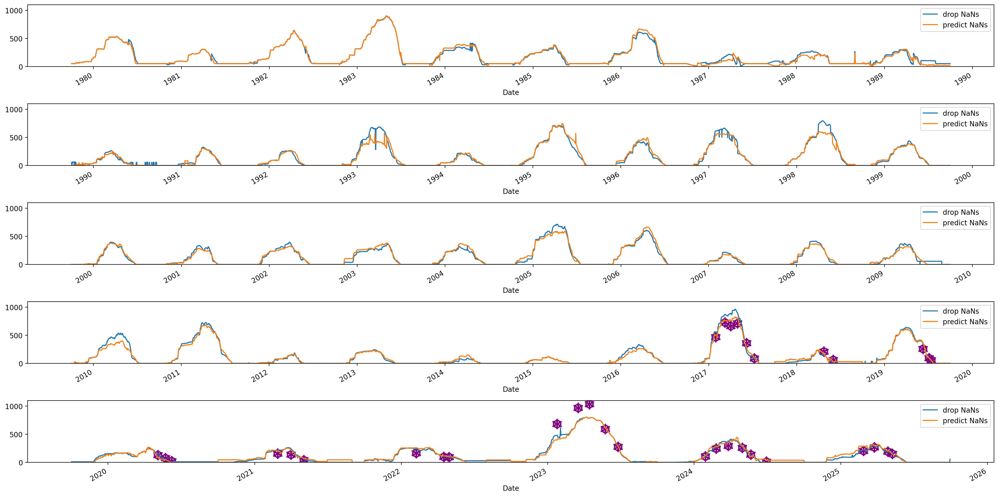

In [63]:
fig,ax = plt.subplots(5,1,dpi = 200,figsize = (20,10))
count = 0
for yr in [1980,1990,2000,2010,2020]:
    df_slice = pred_df_v1_mm[(pred_df_v1_mm['Wateryear'] >= yr) & (pred_df_v1_mm['Wateryear'] <= yr+9)]
    aso_tseries_slice = aso_tseries_ds.where(aso_tseries_ds.date.dt.year >= yr).where(aso_tseries_ds.date.dt.year <= yr+9)
    df_slice[df_slice['Training Infer NaNs'] == 'drop NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C0',label = 'drop NaNs')
    df_slice[df_slice['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C1',label = 'predict NaNs')
    ax[count].scatter(aso_tseries_slice.date.values,aso_tseries_slice.aso_swe[:,-1].values,marker=u'$\u2744$', s=200,color = 'purple',label = 'ASO')
    ax[count].set_ylim(0,1100)
    count += 1
plt.tight_layout()

## v2

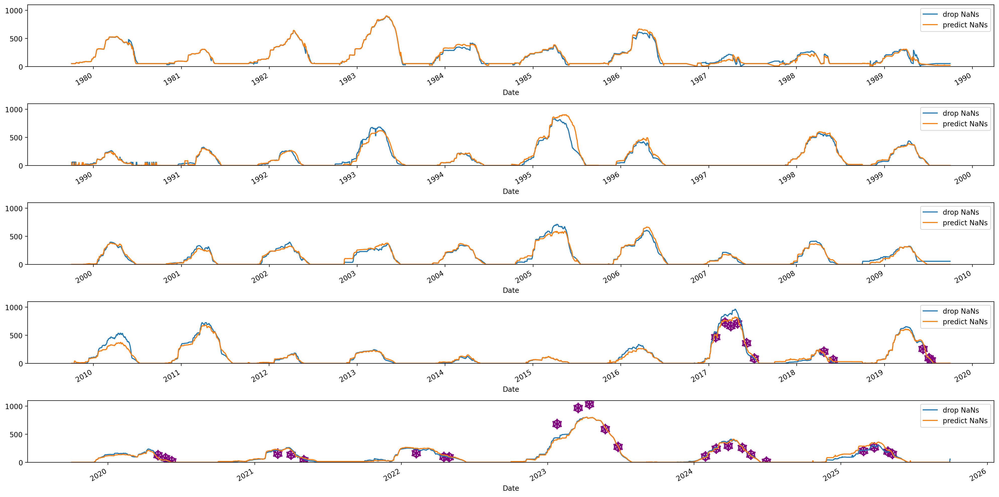

In [64]:
fig,ax = plt.subplots(5,1,dpi = 200,figsize = (20,10))
count = 0
for yr in [1980,1990,2000,2010,2020]:
    df_slice = pred_df_v2_mm[(pred_df_v2_mm['Wateryear'] >= yr) & (pred_df_v2_mm['Wateryear'] <= yr+9)]
    aso_tseries_slice = aso_tseries_ds.where(aso_tseries_ds.date.dt.year >= yr).where(aso_tseries_ds.date.dt.year <= yr+9)
    df_slice[df_slice['Training Infer NaNs'] == 'drop NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C0',label = 'drop NaNs')
    df_slice[df_slice['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C1',label = 'predict NaNs')
    ax[count].scatter(aso_tseries_slice.date.values,aso_tseries_slice.aso_swe[:,-1].values,marker=u'$\u2744$', s=200,color = 'purple',label = 'ASO')
    ax[count].set_ylim(0,1100)
    count += 1
plt.tight_layout()

## v3

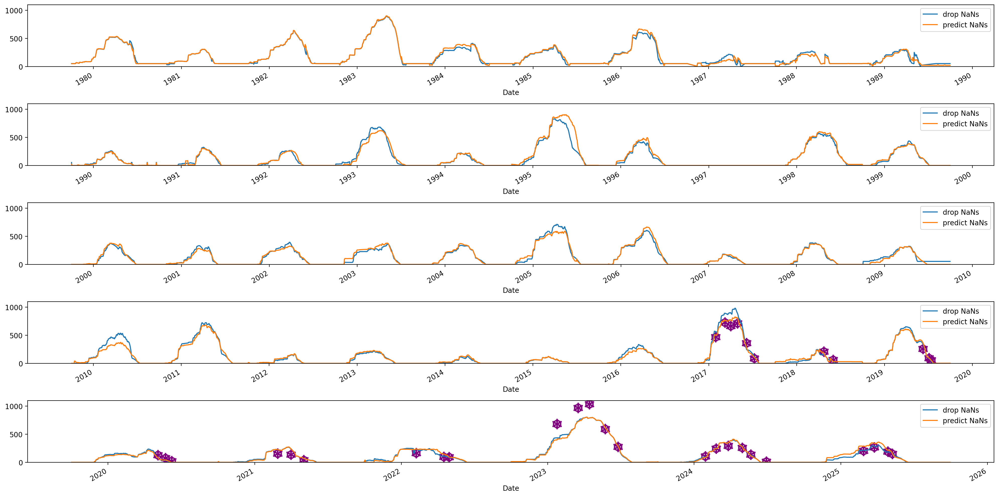

In [65]:
fig,ax = plt.subplots(5,1,dpi = 200,figsize = (20,10))
count = 0
for yr in [1980,1990,2000,2010,2020]:
    df_slice = pred_df_v3_mm[(pred_df_v3_mm['Wateryear'] >= yr) & (pred_df_v3_mm['Wateryear'] <= yr+9)]
    aso_tseries_slice = aso_tseries_ds.where(aso_tseries_ds.date.dt.year >= yr).where(aso_tseries_ds.date.dt.year <= yr+9)
    df_slice[df_slice['Training Infer NaNs'] == 'drop NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C0',label = 'drop NaNs')
    df_slice[df_slice['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C1',label = 'predict NaNs')
    ax[count].scatter(aso_tseries_slice.date.values,aso_tseries_slice.aso_swe[:,-1].values,marker=u'$\u2744$', s=200,color = 'purple',label = 'ASO')
    ax[count].set_ylim(0,1100)
    count += 1
plt.tight_layout()

## v4

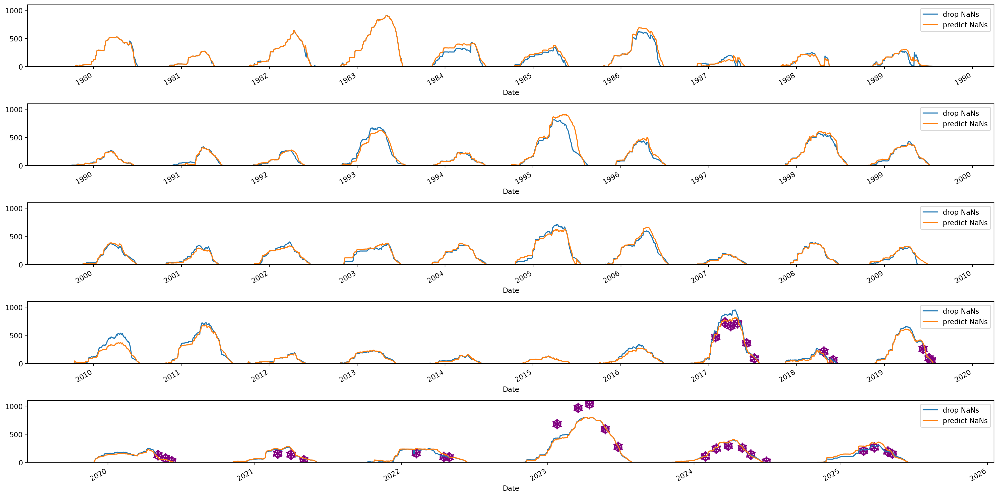

In [66]:
fig,ax = plt.subplots(5,1,dpi = 200,figsize = (20,10))
count = 0
for yr in [1980,1990,2000,2010,2020]:
    df_slice = pred_df_v4_mm[(pred_df_v4_mm['Wateryear'] >= yr) & (pred_df_v4_mm['Wateryear'] <= yr+9)]
    aso_tseries_slice = aso_tseries_ds.where(aso_tseries_ds.date.dt.year >= yr).where(aso_tseries_ds.date.dt.year <= yr+9)
    df_slice[df_slice['Training Infer NaNs'] == 'drop NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C0',label = 'drop NaNs')
    df_slice[df_slice['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C1',label = 'predict NaNs')
    ax[count].scatter(aso_tseries_slice.date.values,aso_tseries_slice.aso_swe[:,-1].values,marker=u'$\u2744$', s=200,color = 'purple',label = 'ASO')
    ax[count].set_ylim(0,1100)
    count += 1
plt.tight_layout()

## v5

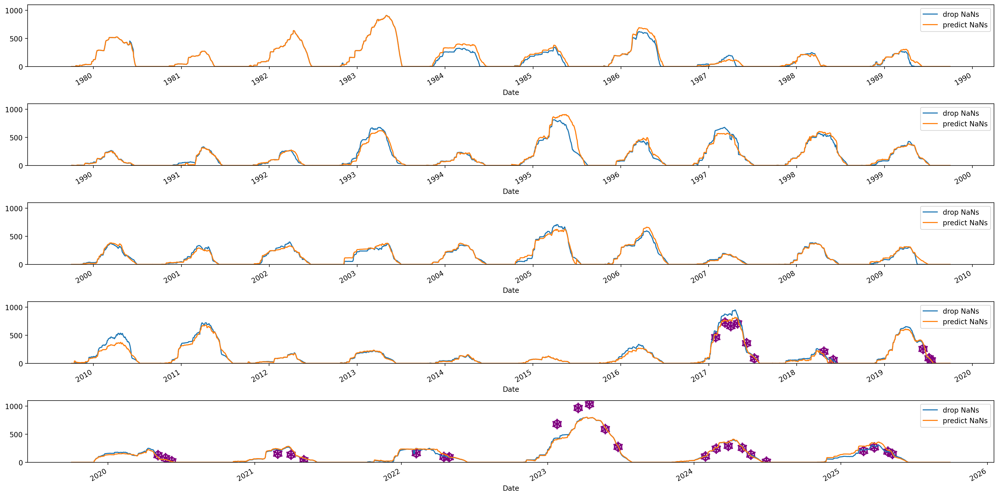

In [67]:
fig,ax = plt.subplots(5,1,dpi = 200,figsize = (20,10))
count = 0
for yr in [1980,1990,2000,2010,2020]:
    df_slice = pred_df_v5_mm[(pred_df_v5_mm['Wateryear'] >= yr) & (pred_df_v5_mm['Wateryear'] <= yr+9)]
    aso_tseries_slice = aso_tseries_ds.where(aso_tseries_ds.date.dt.year >= yr).where(aso_tseries_ds.date.dt.year <= yr+9)
    df_slice[df_slice['Training Infer NaNs'] == 'drop NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C0',label = 'drop NaNs')
    df_slice[df_slice['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C1',label = 'predict NaNs')
    ax[count].scatter(aso_tseries_slice.date.values,aso_tseries_slice.aso_swe[:,-1].values,marker=u'$\u2744$', s=200,color = 'purple',label = 'ASO')
    ax[count].set_ylim(0,1100)
    count += 1
plt.tight_layout()

In [68]:
import copy
all_cols = df_slice.columns.to_list()
elev_bins = copy.deepcopy(all_cols)
elev_bins.remove('Date')
elev_bins.remove('Model Type')
elev_bins.remove('Training Infer NaNs')
elev_bins.remove('Prediction QA')
elev_bins.remove('Wateryear')
elev_bins

['<7k', '7k-8k', '8k-9k', '9k-10k', '10k-11k', '11k-12k', '>12k', 'Basin']

In [44]:
aso_tseries_ds.elev

<xarray.DataArray 'elev' (elev: 8)> Size: 352B
array(['<7000', '7000-8000', '8000-9000', '9000-10000', '10000-11000',
       '11000-12000', '>12000', 'total'], dtype='<U11')
Coordinates:
  * elev     (elev) <U11 352B '<7000' '7000-8000' ... '>12000' 'total'

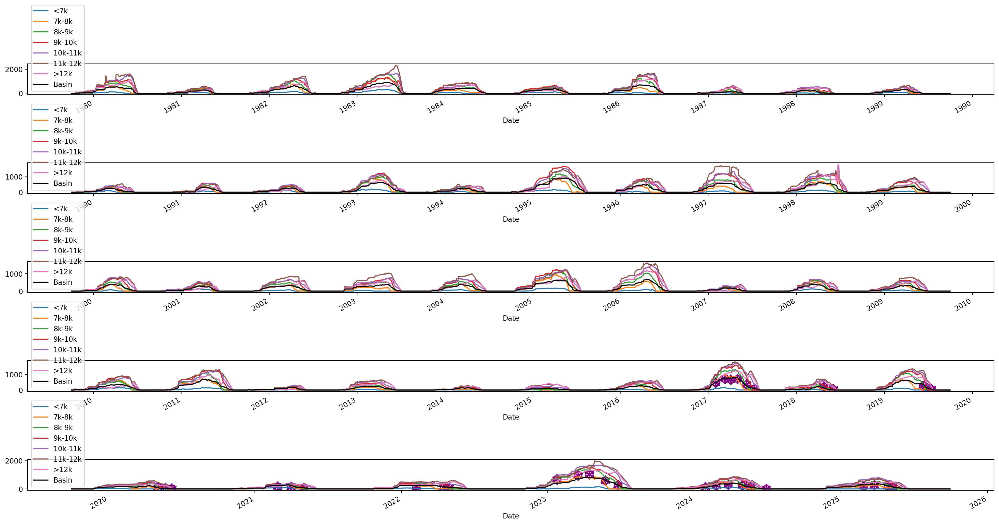

In [69]:
model = 'predict NaNs'
fig,ax = plt.subplots(5,1,dpi = 200,figsize = (20,10))
count = 0
for yr in [1980,1990,2000,2010,2020]:
    df_slice = pred_df_v5_mm[(pred_df_v5_mm['Wateryear'] >= yr) & (pred_df_v5_mm['Wateryear'] <= yr+9) & (pred_df_v5_mm['Training Infer NaNs'] >= model)]
    for bin in elev_bins:
        if bin == 'Basin':
            df_slice.plot(ax=ax[count],x = 'Date',y=bin,label = bin,color = 'black',linewidth = 1.5)
        else:
            df_slice.plot(ax=ax[count],x = 'Date',y=bin,label = bin)
    aso_tseries_slice = aso_tseries_ds.where(aso_tseries_ds.date.dt.year >= yr).where(aso_tseries_ds.date.dt.year <= yr+9)

    ax[count].scatter(aso_tseries_slice.date.values,aso_tseries_slice.aso_swe[:,-1].values,marker=u'$\u2744$', s=200,color = 'purple',label = 'ASO')
    # ax[count].set_ylim(0,1100)
    count += 1
plt.tight_layout()

In [37]:
aso_tseries_ds.aso_swe[:,0].values.max()

np.float64(268.68497550583606)

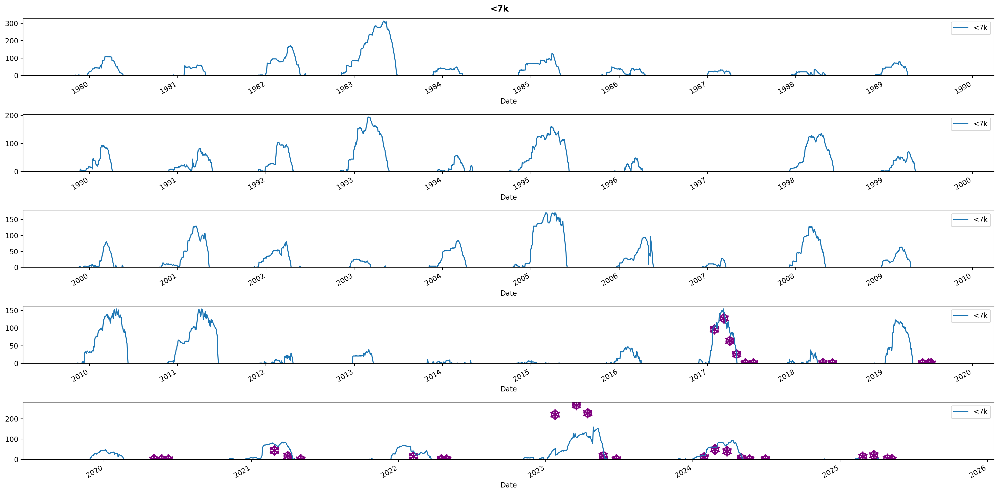

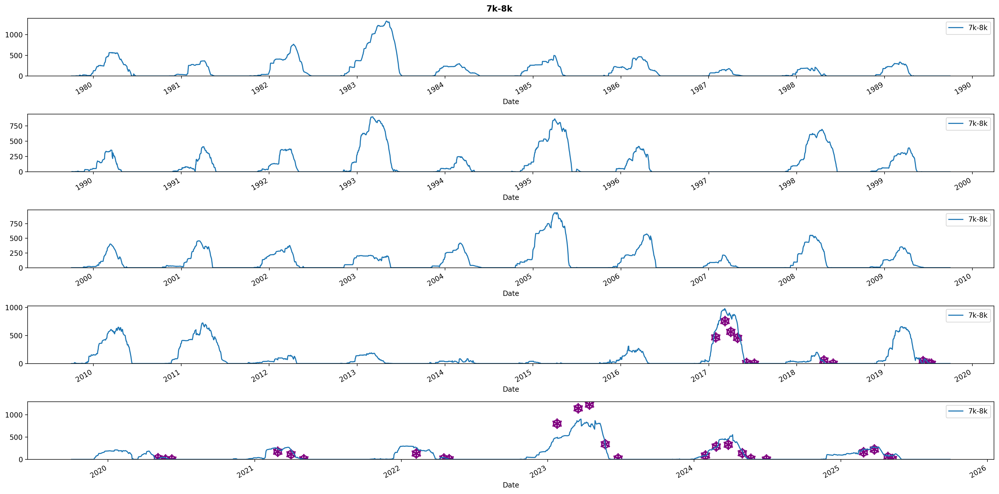

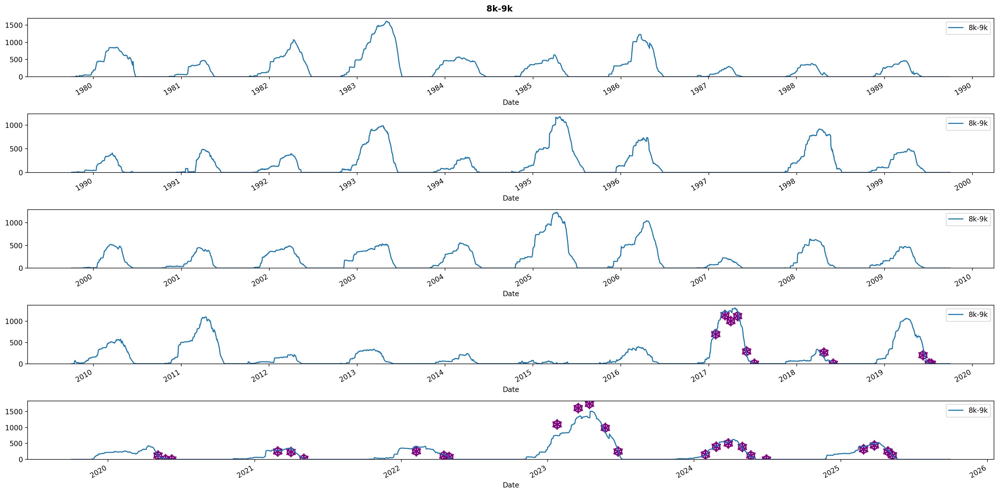

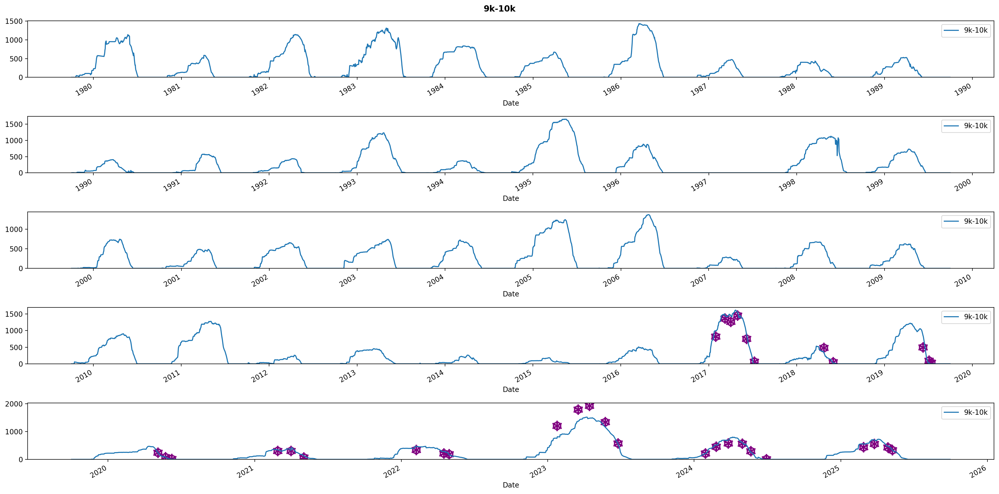

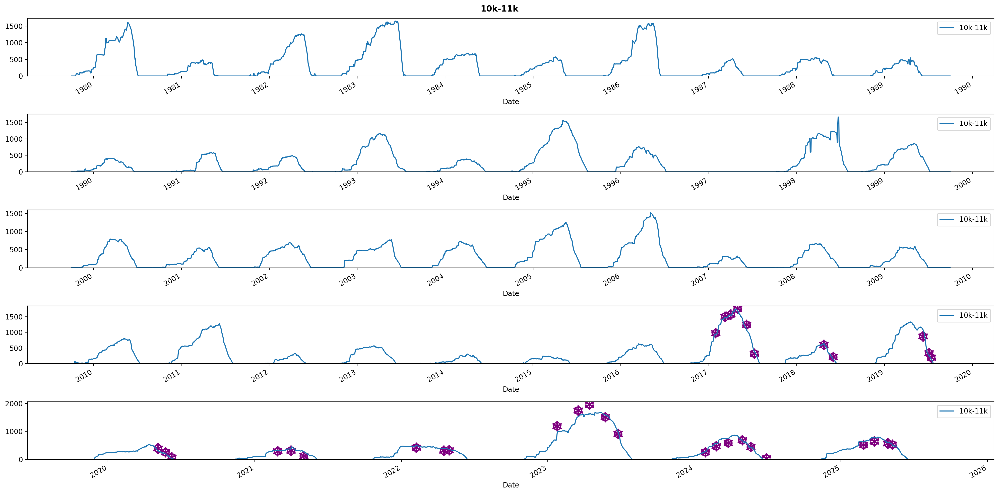

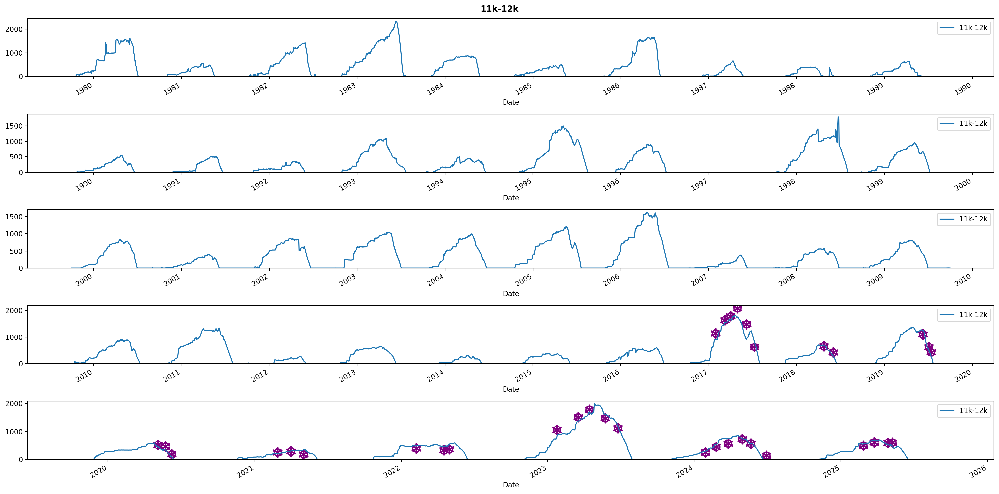

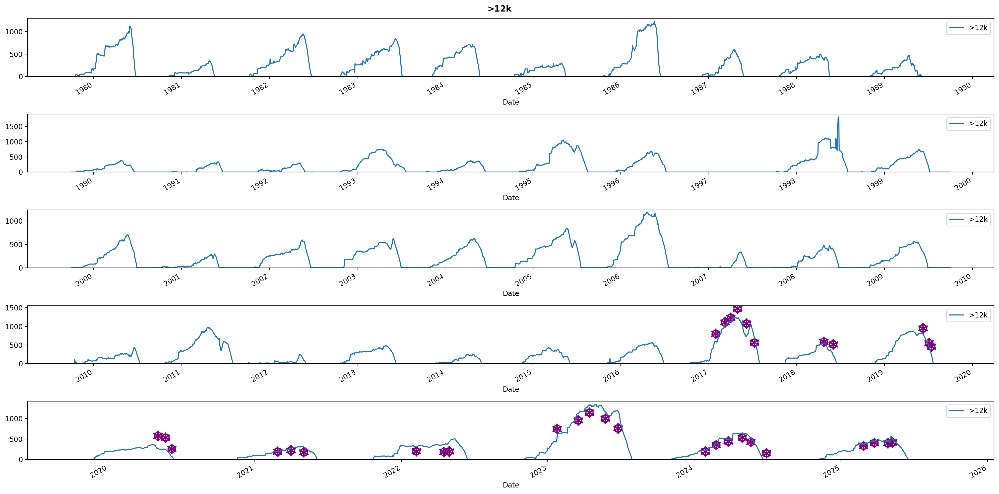

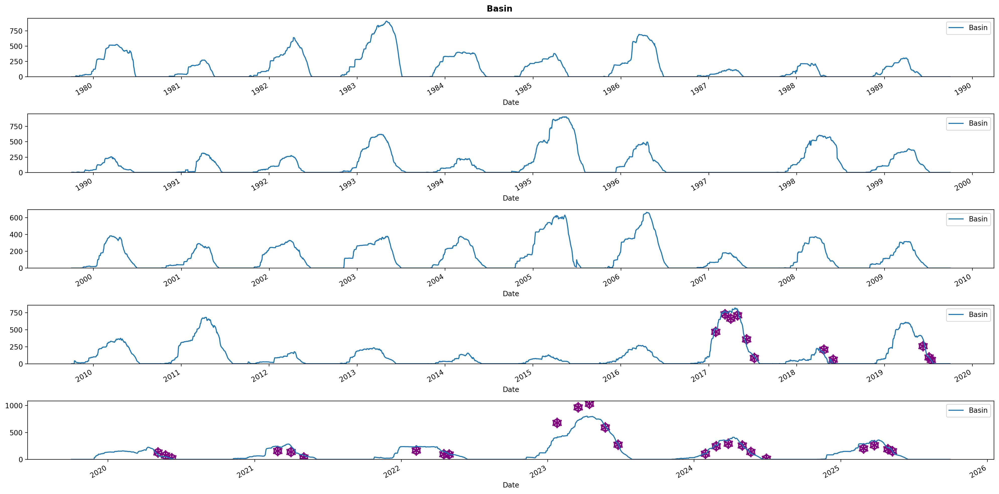

In [42]:
model = 'predict NaNs'
count2 = 0
for bin in elev_bins:
    fig,ax = plt.subplots(5,1,dpi = 200,figsize = (20,10))
    count = 0
    for yr in [1980,1990,2000,2010,2020]:
        df_slice = pred_df_v5_mm[(pred_df_v5_mm['Wateryear'] >= yr) & (pred_df_v5_mm['Wateryear'] <= yr+9) & (pred_df_v5_mm['Training Infer NaNs'] >= model)]
        df_slice.plot(ax=ax[count],x = 'Date',y=bin,label = bin)
        aso_tseries_slice = aso_tseries_ds.where(aso_tseries_ds.date.dt.year >= yr).where(aso_tseries_ds.date.dt.year <= yr+9)

        ax[count].scatter(aso_tseries_slice.date.values,aso_tseries_slice.aso_swe[:,count2].values,marker=u'$\u2744$', s=200,color = 'purple',label = 'ASO')
        ax[count].set_ylim(0,None)
        count += 1
    count2 += 1
    plt.suptitle(bin,fontweight = 'bold')
    plt.tight_layout()
    # plt.suptitle(bin,fontweight = 'bold')
    plt.show()


In [40]:
aso_tseries_slice.aso_swe[:,count].values

array([          nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,  521.75697189,
        466.48303984,  189.03282835,  247.6898199 ,  283.41557257,
        175.49832818,  393.4802798 ,  330.96522382,  371.06174058,
       1060.70204763, 1518.97186687, 1779.75047482, 1485.6417828 ,
       1120.5357191 ,  247.83393474,  448.24860494,  567.87390405,
        723.83504773,  562.29550225,  130.10849234,  493.05103422,
        608.50894268,  590.8013474 ,  597.91975607])

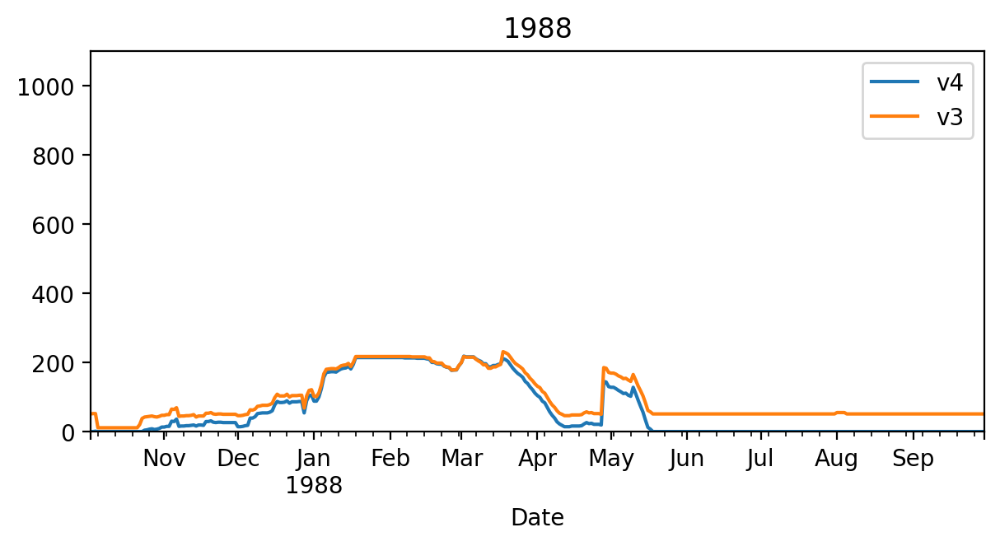

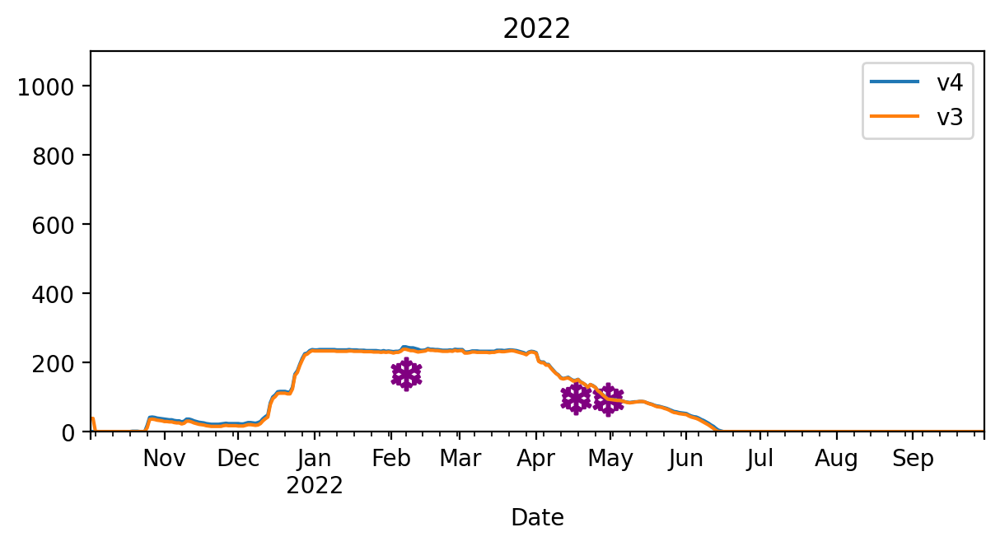

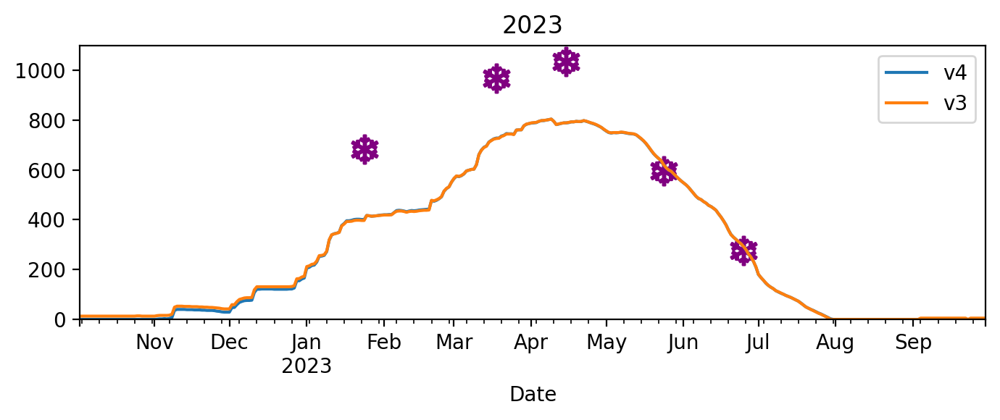

In [31]:
for yr in [1988,2022,2023]:
    fig,ax = plt.subplots(dpi = 200,figsize = (7,3))
    df_slice_v1 = pred_df_v3_mm[(pred_df_v3_mm['Wateryear'] == yr)]
    df_slice_v0 = pred_df_v4_mm[(pred_df_v4_mm['Wateryear'] == yr)]
    aso_tseries_slice = aso_tseries_ds.where(aso_tseries_ds.date.dt.year >= yr).where(aso_tseries_ds.date.dt.year <= yr+9)
    df_slice_v0[df_slice_v0['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax,x = 'Date',y='Basin',color = 'C0',label = 'v4')
    df_slice_v1[df_slice_v1['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax,x = 'Date',y='Basin',color = 'C1',label = 'v3')
    ax.scatter(aso_tseries_slice.date.values,aso_tseries_slice.aso_swe[:,-1].values,marker=u'$\u2744$', s=200,color = 'purple',label = 'ASO')
    ax.set_ylim(0,1100)
    ax.set_title(yr)
    count += 1
plt.tight_layout()

## v0/v1 predicted

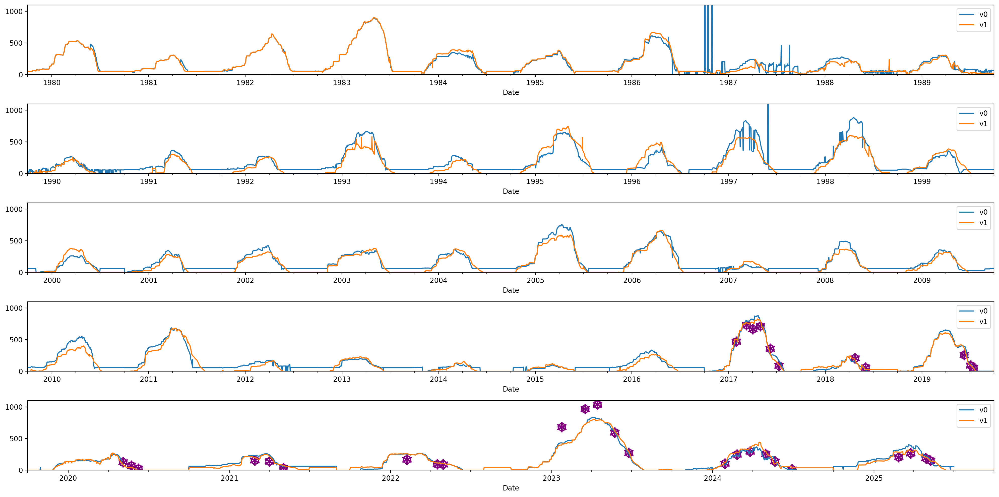

In [18]:
fig,ax = plt.subplots(5,1,dpi = 200,figsize = (20,10))
count = 0
for yr in [1980,1990,2000,2010,2020]:
    df_slice_v1 = pred_df_v1_mm[(pred_df_v1_mm['Wateryear'] >= yr) & (pred_df_v1_mm['Wateryear'] <= yr+9)]
    df_slice_v0 = pred_df_v0_mm[(pred_df_v0_mm['Wateryear'] >= yr) & (pred_df_v0_mm['Wateryear'] <= yr+9)]
    aso_tseries_slice = aso_tseries_ds.where(aso_tseries_ds.date.dt.year >= yr).where(aso_tseries_ds.date.dt.year <= yr+9)
    df_slice_v0[df_slice_v0['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C0',label = 'v0')
    df_slice_v1[df_slice_v1['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C1',label = 'v1')
    ax[count].scatter(aso_tseries_slice.date.values,aso_tseries_slice.aso_swe[:,-1].values,marker=u'$\u2744$', s=200,color = 'purple',label = 'ASO')
    ax[count].set_ylim(0,1100)
    count += 1
plt.tight_layout()

## ASO vs Model Predictions (v0/v1)

In [160]:
str(aso_tseries_ds.elev[-1].values)

'total'

In [ ]:
from sklearn.metrics import root_mean_squared_error

In [ ]:
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

def prediction_v_aso_scatter(aso_tseries_ds: xr.Dataset,
                             pred_df: pd.DataFrame,
                             model_type: str,
                             version: int = 1,
                             elev_idx: int = -1,
                             ):
    aso_df = aso_tseries_ds.aso_swe[:,elev_idx].to_dataframe().drop(columns = 'elev')
    print(f'ASO LENGTH: {len(aso_df)}')
    pred_v1_df = pred_df[(pred_df['Training Infer NaNs'] == model_type) & (pred_df['Date'].isin(aso_tseries_ds.date.values))][['Date','Basin']].rename(columns = {'Date':'date'}).set_index('date')
    print(f'PREDICTION LENGTH: {len(pred_v1_df)}')
    df_merge = pd.merge(left = aso_df,right = pred_v1_df,left_index = True, right_index = True)
    print(f'MERGE LENGTH: {len(df_merge)}')

    r2 = r2_score(df_merge['aso_swe'].values,df_merge['Basin'].values)
    rmse = root_mean_squared_error(df_merge['aso_swe'].values,df_merge['Basin'].values)

    fig,ax = plt.subplots(dpi = 100,figsize = (5,5))
    df_merge.plot(ax=ax,kind = 'scatter',x = 'Basin',y = 'aso_swe',label = f'r2={r2:.2f}\nrmse={rmse:.2f}')
    ax.plot([0,max(df_merge['Basin'].max(),df_merge['aso_swe'].max())+50],[0,max(df_merge['Basin'].max(),df_merge['aso_swe'].max())+50],linestyle = '--',color = 'gray')
    ax.legend()
    plt.xlim(0,max(df_merge['Basin'].max(),df_merge['aso_swe'].max())+50)
    plt.ylim(0,max(df_merge['Basin'].max(),df_merge['aso_swe'].max())+50)
    plt.ylabel('ASO Mean SWE [mm]',fontweight = 'bold')
    plt.xlabel('Predicted Mean SWE [mm]',fontweight = 'bold')
    plt.title(f'v{version} ASO vs Predicted\n{model_type}; {str(aso_tseries_ds.elev[elev_idx].values)}',fontweight = 'bold')
    plt.show()
    return



ASO LENGTH: 35
PREDICTION LENGTH: 35
MERGE LENGTH: 35


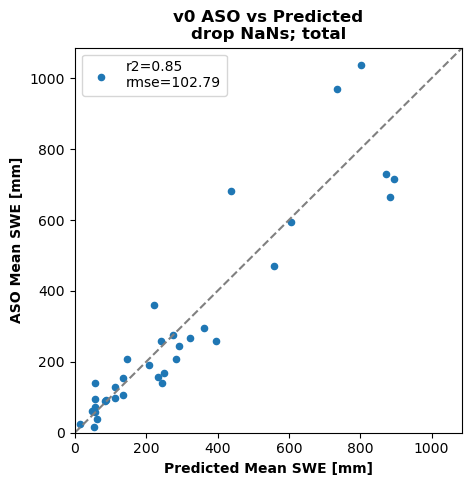

ASO LENGTH: 35
PREDICTION LENGTH: 35
MERGE LENGTH: 35


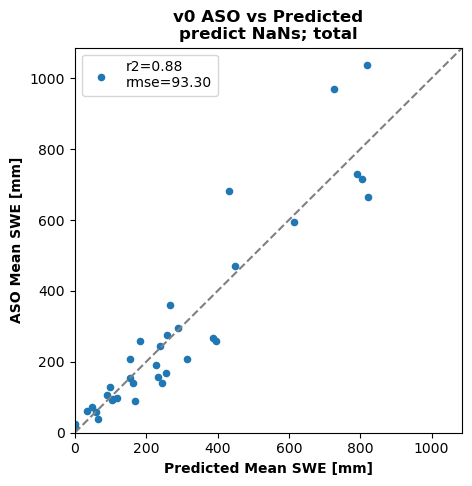

ASO LENGTH: 35
PREDICTION LENGTH: 35
MERGE LENGTH: 35


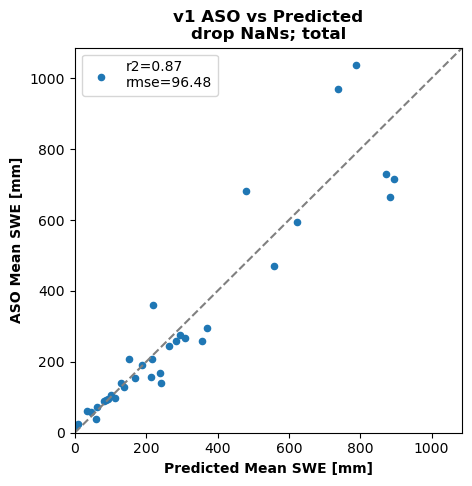

ASO LENGTH: 35
PREDICTION LENGTH: 35
MERGE LENGTH: 35


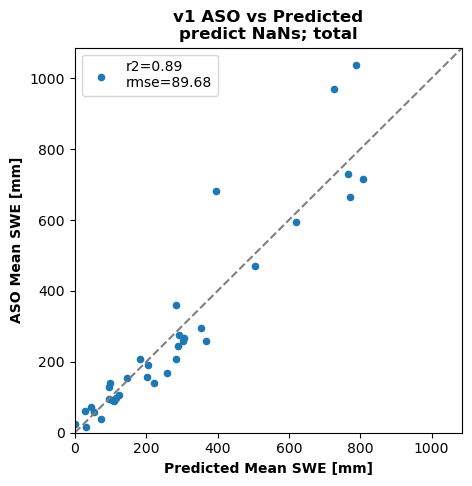

In [180]:
prediction_v_aso_scatter(aso_tseries_ds,
                             pred_df_v0_mm,
                             'drop NaNs',
                             0,
                             elev_idx = -1,
                             )
prediction_v_aso_scatter(aso_tseries_ds,
                             pred_df_v0_mm,
                             'predict NaNs',
                             0,
                             elev_idx = -1,
                             )

prediction_v_aso_scatter(aso_tseries_ds,
                             pred_df_v1_mm,
                             'drop NaNs',
                             1,
                             elev_idx = -1,
                             )
prediction_v_aso_scatter(aso_tseries_ds,
                             pred_df_v1_mm,
                             'predict NaNs',
                             1,
                             elev_idx = -1,
                             )

In [ ]:
aso_df = aso_tseries_ds.aso_swe[:,-1].to_dataframe().drop(columns = 'elev')

,aso_swe
date,
2017-01-29,470.926270
2017-03-09,730.626852
2017-04-02,666.198916
2017-04-30,714.490413
2017-06-06,360.401147
2017-07-09,88.088288
2018-04-23,208.215283
2018-06-01,61.810183
2019-06-09,259.953890


## Pillow selection by year

In [133]:
def highlight_dates(ax, dates, *, span_kw=None, line_kw=None):
    """
    On the given Axes:
      - fill (axvspan) continuous runs of consecutive dates (>=2 days),
      - draw axvline for single, isolated dates.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
    dates : array-like of datetime-like (e.g., pd.Series or DatetimeIndex)
    span_kw : dict for axvspan style (color, alpha, etc.)
    line_kw : dict for axvline style (color, alpha, lw, etc.)
    """
    span_kw = {"color": "C0", "alpha": 0.2} | (span_kw or {})
    line_kw = {"color": "C0", "alpha": 0.8, "lw": 1.5} | (line_kw or {})

    # Make a sorted, unique DatetimeIndex
    idx = pd.to_datetime(pd.Index(dates)).tz_localize(None).sort_values().unique()

    if len(idx) == 0:
        return

    # Group into runs where gaps != 1 day start a new group
    s = pd.Series(idx)
    grp = (s.diff().ne(pd.Timedelta(days=1))).cumsum()

    for _, run in s.groupby(grp):
        if len(run) == 1:
            d = run.iloc[0]
            ax.axvline(d, **line_kw)
        else:
            start = run.iloc[0]
            end = run.iloc[-1] + pd.Timedelta(days=1)  # right-open so the last day is fully shaded
            ax.axvspan(start, end, **span_kw)

def prediction_pillows_tseries(pred_df: pd.DataFrame,
                               pils_df: pd.DataFrame,
                               aso_tseries_ds: xr.Dataset,
                               obs_data_hist: xr.Dataset,
                               water_year: int,
                               model_type: str = 'predict NaNs',
                               version: int = 1):
    
    pred_QA2_mm = pred_df[pred_df['Wateryear'] == water_year]
    pillows_QA2_mm = pils_df[pils_df['Wateryear'] == water_year]
    majority_pils = pillows_QA2_mm[pillows_QA2_mm['Training Infer NaNs'] == model_type].groupby('Basin').count().sort_values('Date',ascending = False).reset_index().iloc[0]['Basin']
    print(majority_pils)
    # for pils in pillows_QA2_mm[pillows_QA2_mm['Training Infer NaNs'] == 'predict NaNs']['Basin'].unique():
    fig,ax = plt.subplots(2,1,figsize = (9,5),dpi = 200,sharex = True)
    aso_tseries_slice = aso_tseries_ds.where(aso_tseries_ds.date.dt.year == water_year)
    pred_QA2_mm[pred_QA2_mm['Training Infer NaNs'] == 'drop NaNs'].plot(ax=ax[0],x = 'Date',y='Basin',color = 'C0',label = 'drop NaNs')
    pred_QA2_mm[pred_QA2_mm['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[0],x = 'Date',y='Basin',color = 'C1',label = 'predict NaNs')
    ax[0].scatter(aso_tseries_slice.date.values,aso_tseries_slice.aso_swe[:,-1].values,marker=u'$\u2744$', s=200,color = 'purple',label = 'ASO')
    
    pil_slice_df = pillows_QA2_mm[(pillows_QA2_mm['Training Infer NaNs'] == model_type) & (pillows_QA2_mm['Basin'] == majority_pils)]
    highlight_dates(ax[0], pil_slice_df['Date'], span_kw={"color":"tab:orange","alpha":0.25},
                        line_kw={"color":"tab:orange","lw":1.2})
    ax[0].set_title(f'v{version} Basin SWE Predictions: {water_year}',fontweight = 'bold')
    ax[0].set_ylabel('Basin Mean SWE [mm]')

    # pils = pillows_QA2_mm[pillows_QA2_mm['Training Infer NaNs'] == 'drop NaNs']['Basin'].unique()
    for pil in majority_pils.split(', '):
        # idx_ = [i for i in range(0,len(obs_data_hist)) if obs_data_hist[i].name == pil][0]
        da_slice = obs_data_hist[pil].where(obs_data_hist[pil].time >= np.datetime64(pred_QA2_mm['Date'].iloc[0]),drop = True).where(obs_data_hist[pil].time <= np.datetime64(pred_QA2_mm['Date'].iloc[-1]),drop = True)
        da_slice.plot(ax=ax[1],label = pil)
    ax[1].legend()
    ax[1].set_ylabel('SWE [mm]')
    highlight_dates(ax[1], pil_slice_df['Date'], span_kw={"color":"tab:orange","alpha":0.25},
                        line_kw={"color":"tab:orange","lw":1.2})
    ax[1].set_title(f'{model_type} Pillows',fontweight = 'bold')
    plt.tight_layout()
    plt.show()
    return

In [110]:
pillows_QA2_mm = pred_df_v1_pillows[pred_df_v1_pillows['Wateryear'] == water_year]
pillows_QA2_mm

,Date,Model Type,Training Infer NaNs,Prediction QA,<7k,7k-8k,8k-9k,9k-10k,10k-11k,11k-12k,>12k,Basin,Wateryear
10930,1996-10-02,MLR,drop NaNs,1,"PSR, SWM, TUM","PSR, SWM","CHM, KSP, SWM","CHM, KSP, LLE","KSP, LLE","CHM, DAN, KSP, LLE","CHM, DAN, KSP, LLE","LLE, PSR, STL",1997
10931,1996-10-02,MLR,predict NaNs,1,"HNT, PSR","BGP, PSR, STR, SWM","BGP, GEM, SWM, WWC","GEM, HNT, MHP, SWM, WWC","HNT, KSP, LLE, MHP, PSR","CHM, GRM, LLE, STL","BGP, CHM, DAN, LLE, MHP","GEM, KSP, LLE, SWM",1997
10932,1996-10-03,MLR,drop NaNs,1,"PSR, SWM, TUM","PSR, SWM","CHM, KSP, SWM","CHM, KSP, LLE","KSP, LLE","CHM, DAN, KSP, LLE","CHM, DAN, KSP, LLE","LLE, PSR, STL",1997
10933,1996-10-03,MLR,predict NaNs,1,"HNT, PSR","BGP, PSR, STR, SWM","BGP, GEM, SWM, WWC","GEM, HNT, MHP, SWM, WWC","HNT, KSP, LLE, MHP, PSR","CHM, GRM, LLE, STL","BGP, CHM, DAN, LLE, MHP","GEM, KSP, LLE, SWM",1997
10934,1996-10-04,MLR,drop NaNs,1,"PSR, SWM, TUM","PSR, SWM","CHM, KSP, SWM","CHM, KSP, LLE","KSP, LLE","CHM, DAN, KSP, LLE","CHM, DAN, KSP, LLE","LLE, PSR, STL",1997
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11653,1997-09-28,MLR,predict NaNs,1,"HNT, PSR","BGP, PSR, STR, SWM","BGP, GEM, SWM, WWC","GEM, HNT, MHP, SWM, WWC","HNT, KSP, LLE, MHP, PSR","CHM, GRM, LLE, STL","BGP, CHM, DAN, LLE, MHP","GEM, KSP, LLE, SWM",1997
11654,1997-09-29,MLR,drop NaNs,1,"PSR, SWM, TUM","PSR, SWM","CHM, KSP, SWM","CHM, KSP, LLE","KSP, LLE","CHM, DAN, KSP, LLE","CHM, DAN, KSP, LLE","LLE, PSR, STL",1997
11655,1997-09-29,MLR,predict NaNs,1,"HNT, PSR","BGP, PSR, STR, SWM","BGP, GEM, SWM, WWC","GEM, HNT, MHP, SWM, WWC","HNT, KSP, LLE, MHP, PSR","CHM, GRM, LLE, STL","BGP, CHM, DAN, LLE, MHP","GEM, KSP, LLE, SWM",1997
11656,1997-09-30,MLR,drop NaNs,1,"PSR, SWM, TUM","PSR, SWM","CHM, KSP, SWM","CHM, KSP, LLE","KSP, LLE","CHM, DAN, KSP, LLE","CHM, DAN, KSP, LLE","LLE, PSR, STL",1997


In [127]:
pillows_QA2_mm.groupby('Basin').count().sort_values('Date',ascending = False).reset_index().iloc[0]['Basin']

'LLE, PSR, STL'

GEM, LLE, SWM, WWC


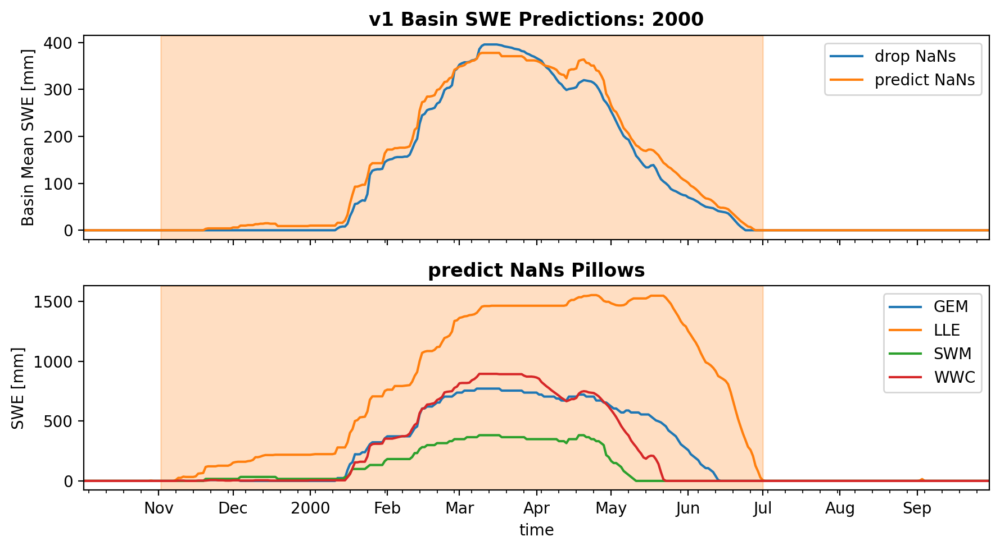

CHM, KSP, LLE


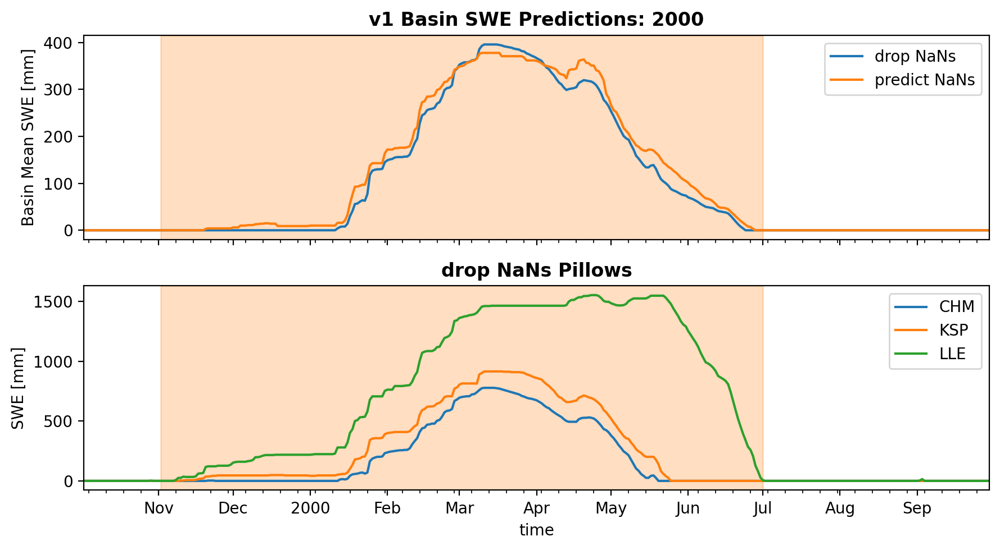

In [185]:
prediction_pillows_tseries(pred_df_v1_mm,
                               pred_df_v1_pillows,
                               aso_tseries_ds,
                               obs_data_train_ds,
                               2000,
                               model_type = 'predict NaNs',
                               version = 1)

prediction_pillows_tseries(pred_df_v1_mm,
                               pred_df_v1_pillows,
                               aso_tseries_ds,
                               obs_data_train_ds,
                               2000,
                               model_type = 'drop NaNs',
                               version = 1)

In [ ]:
for pils in pred_QA2_mm[pred_QA2_mm['Training Infer NaNs'] == 'predict NaNs']['Basin'].unique():
    fig,ax = plt.subplots(2,1,figsize = (9,5),dpi = 200,sharex = True)
    aso_tseries_slice = aso_tseries_1.where(aso_tseries_1.date.dt.year == 2025)
    pred_QA2_mm[pred_QA2_mm['Training Infer NaNs'] == 'drop NaNs'].plot(ax=ax[0],x = 'Date',y='Basin',color = 'C0',label = 'drop NaNs')
    pred_QA2_mm[pred_QA2_mm['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[0],x = 'Date',y='Basin',color = 'C1',label = 'predict NaNs')
    ax[0].scatter(aso_tseries_slice.date.values,aso_tseries_slice.aso_swe[:,-1].values,marker=u'$\u2744$', s=200,color = 'purple',label = 'ASO')
    
    pil_slice_df = pillows_QA2_mm[(pillows_QA2_mm['Training Infer NaNs'] == 'predict NaNs') & (pillows_QA2_mm['Basin'] == pils)]
    highlight_dates(ax[0], pil_slice_df['Date'], span_kw={"color":"tab:orange","alpha":0.25},
                        line_kw={"color":"tab:orange","lw":1.2})
    ax[0].set_title(f'QA-2 Basin SWE Predictions\n{pils}',fontweight = 'bold')
    ax[0].set_ylabel('Basin Mean SWE [mm]')
    
    for pil in pils.split(', '):
        idx_ = [i for i in range(0,len(obs_data_hist)) if obs_data_hist[i].name == pil][0]
        da_slice = obs_data_hist[idx_].where(obs_data_hist[idx_].time >= np.datetime64(pred_QA2_mm['Date'].iloc[0]),drop = True).where(obs_data_hist[idx_].time <= np.datetime64(pred_QA2_mm['Date'].iloc[-1]),drop = True)
        da_slice.plot(ax=ax[1],label = pil)
    ax[1].legend()
    ax[1].set_ylabel('SWE [mm]')
    highlight_dates(ax[1], pil_slice_df['Date'], span_kw={"color":"tab:orange","alpha":0.25},
                        line_kw={"color":"tab:orange","lw":1.2})
    ax[1].set_title('Pillow Time Series',fontweight = 'bold')
                                                                                                                                      
                                                                                                                                      
    break